# 01 - Bayesian Knowledge Tracing (BKT) - Baseline

## Proyecto Lairn - Microservicio de Knowledge Tracing

Este notebook implementa el modelo **Bayesian Knowledge Tracing (BKT)** como **baseline obligatorio** del sistema de aprendizaje adaptativo Lairn. Es el primer modelo de la serie:

- `01_bkt.ipynb` <-  (baseline)
- `02_dkt.ipynb` (Deep Knowledge Tracing)
- `03_sakt.ipynb` (Self-Attentive Knowledge Tracing)

### Que hace BKT?

BKT modela el aprendizaje del estudiante como una **cadena de Markov oculta de 2 estados** (dominado / no dominado) y estima 4 parametros por concepto via Expectation-Maximization:

| Parametro | Significado |
|-----------|-------------|
| `p_init` (P(L0)) | Probabilidad de saber el concepto antes de empezar |
| `p_learn` (P(T)) | Probabilidad de aprender en cada intento |
| `p_guess` (P(G)) | Probabilidad de acertar sin saber (suerte) |
| `p_slip` (P(S)) | Probabilidad de fallar sabiendo (descuido) |

Despues de cada interaccion actualizamos P(L) con regla de Bayes y aplicamos la transicion P(T). Cuando `P(L) >= 0.80` consideramos el concepto **dominado**.

### Datos

- **50 estudiantes** ficticios
- **3 conceptos**: `derivada_seno`, `derivada_coseno`, `regla_cadena`
- **5-15 interacciones** por (estudiante, concepto)
- Patron **sigmoidal de aprendizaje** (empieza fallando, mejora con la practica)

### Metricas esperadas

- **AUC-ROC ~ 0.67** (objetivo principal del baseline)
- Accuracy, F1, RMSE como complementarias

### Buenas practicas aplicadas

1. Split **por estudiante** (no por interaccion) -> evita data leakage
2. `random_state=42` en todo
3. Validacion de datos antes de entrenar
4. Constantes al inicio (sin numeros magicos)
5. Funciones con docstrings
6. Persistencia de modelo + metricas + config

## 1️ Setup inicial — Imports y configuración

Cargamos las librerías necesarias:
- **numpy, pandas**: matemáticas y tablas
- **matplotlib, seaborn**: gráficas
- **scikit-learn**: split train/test y métricas
- **`src/bkt_modelo.BKTModel`**: nuestra implementación BKT en NumPy puro (sin `pyBKT` porque no tiene wheels para Python 3.14)
- **`data/generador_datos`**: el generador de datos ficticios con 7 fuentes de variabilidad


In [30]:
# ============================================================================
# CELDA 1 - IMPORTS Y CONFIGURACION GLOBAL
# ============================================================================

# sys nos permite modificar el path de Python para importar desde data/ y src/
import sys
# os para variables de entorno (silenciar warnings si aparecen)
import os
# json para guardar metricas y config en formato legible
import json
# pickle para serializar el modelo entrenado a disco
import pickle
# Path para rutas multiplataforma (Windows/Linux/Mac)
from pathlib import Path

# numpy para operaciones numericas vectorizadas
import numpy as np
# pandas para manipulacion del DataFrame de interacciones
import pandas as pd
# matplotlib para graficas base
import matplotlib.pyplot as plt
# seaborn para graficas estadisticas (heatmap, histogramas mas bonitos)
import seaborn as sns

# train_test_split de sklearn para dividir estudiantes en train/test
from sklearn.model_selection import train_test_split
# Metricas de evaluacion estandar para clasificacion binaria
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, mean_squared_error

# Agregamos la raiz del proyecto al path para importar nuestros modulos propios
# Path('.').resolve() = directorio actual; .parent = subir un nivel desde notebooks/
ROOT = Path('.').resolve().parent
# Insertamos al inicio del path para que Python lo encuentre primero
sys.path.insert(0, str(ROOT))

# Importamos nuestro generador de datos ficticios (modulo en data/)
from data.generador_datos import generar_dataset, guardar_dataset
# Importamos NUESTRA implementacion de BKT en NumPy puro (sin pyBKT).
# pyBKT requiere compilacion C++ que falla en Python 3.14 / Windows sin MSVC.
# Nuestra implementacion: HMM 2-estados + Baum-Welch (EM) - 100% NumPy.
from src.bkt_modelo import BKTModel

# Estilo visual consistente para todas las graficas del notebook
sns.set_theme(style='whitegrid', palette='deep')
# Tamano de figura por defecto para que se vea bien inline
plt.rcParams['figure.figsize'] = (10, 6)
# DPI moderado para que las graficas sean nitidas pero rapidas de renderizar
plt.rcParams['figure.dpi'] = 100

# Mensaje claro para confirmar que los imports funcionaron
print('[OK] Imports y configuracion global cargados correctamente')

[OK] Imports y configuracion global cargados correctamente


In [31]:
# ============================================================================
# CELDA 2 - CONSTANTES CONFIGURABLES
# ============================================================================
# Centralizamos TODOS los valores configurables aqui para evitar numeros
# magicos dispersos por el codigo (buena practica #7).

# --- Semilla global (reproducibilidad total) ---
SEED = 42

# --- FUENTE DE DATOS ---
# Cambia este valor para alternar entre dataset sintetico++ y real:
#   'sintetico' -> usa data/generador_datos.py (variabilidad simulada)
#   'real'      -> usa data/descargar_assistments.py (~3000 estudiantes reales)
FUENTE_DATOS = 'sintetico'

# --- Configuracion del dataset sintetico ---
# (solo se usa si FUENTE_DATOS == 'sintetico')
N_ESTUDIANTES = 1000
CONCEPTOS_SINTETICOS = ['derivada_seno', 'derivada_coseno', 'regla_cadena']
MIN_INTERACCIONES = 5
MAX_INTERACCIONES = 15

# --- Configuracion del dataset real ---
# (solo se usa si FUENTE_DATOS == 'real')
# ASSISTments tiene 110 skills; limitamos a los TOP_K mas frecuentes
# para entrenar en tiempo razonable. 10 skills cubren ~60% de las interacciones.
TOP_K_SKILLS_REAL = 10

# --- Split train/test ---
TEST_SIZE = 0.30

# --- Parametros del entrenamiento BKT ---
MAX_ITER = 200          # iteraciones maximas del EM
TOLERANCIA = 1e-4       # criterio de convergencia
NUM_FITS = 5            # numero de reinicios aleatorios

# --- Umbral de dominio ---
UMBRAL_DOMINIO = 0.80

# --- Rutas de salida ---
RUTA_DATASET = ROOT / 'data' / 'interacciones.csv'
CARPETA_MODELO = ROOT / 'modelos' / f'bkt_{FUENTE_DATOS}'
RUTA_MODELO = CARPETA_MODELO / 'model.pkl'
RUTA_METRICAS = CARPETA_MODELO / 'metrics.json'
RUTA_CONFIG = CARPETA_MODELO / 'config.json'

# Creamos la carpeta de salida si no existe
CARPETA_MODELO.mkdir(parents=True, exist_ok=True)

# Resumen para auditoria visual
print(f'[CONFIG] Fuente de datos: {FUENTE_DATOS.upper()}')
print(f'   - Semilla: {SEED}')
print(f'   - Test size: {TEST_SIZE:.0%}')
print(f'   - EM: max_iter={MAX_ITER}, tol={TOLERANCIA}, restarts={NUM_FITS}')
print(f'   - Umbral dominio: {UMBRAL_DOMINIO}')
if FUENTE_DATOS == 'sintetico':
    print(f'   - Estudiantes sinteticos: {N_ESTUDIANTES}')
    print(f'   - Conceptos: {CONCEPTOS_SINTETICOS}')
else:
    print(f'   - Dataset: ASSISTments 2009-2010 (real)')
    print(f'   - Filtrar a top-{TOP_K_SKILLS_REAL} skills mas frecuentes')

[CONFIG] Fuente de datos: SINTETICO
   - Semilla: 42
   - Test size: 30%
   - EM: max_iter=200, tol=0.0001, restarts=5
   - Umbral dominio: 0.8
   - Estudiantes sinteticos: 1000
   - Conceptos: ['derivada_seno', 'derivada_coseno', 'regla_cadena']


## 2️ Carga de datos

Se decide qué fuente usar según `FUENTE_DATOS` (celda anterior):

| Fuente | Origen | Tamaño esperado |
|--------|--------|-----------------|
| `'sintetico'` | Generador propio (offline) | ~30.000 filas, 3 skills |
| `'real'` | ASSISTments 2009-2010 (descarga 1 vez) | ~80.000 filas, 10 skills (top-10 de 110) |

El dataset se guarda en `data/interacciones.csv` para que los notebooks DKT y SAKT usen **los mismos datos**.


In [32]:
# ============================================================================
# CELDA 3 - CARGA DE DATOS (sintetico O real)
# ============================================================================
# Segun FUENTE_DATOS:
#   - 'sintetico' -> genera via data/generador_datos.py (1000 estudiantes ficticios
#                    con 7 fuentes de variabilidad: perfiles, dificultad, dependencias,
#                    olvido, fatiga, ruido, sesiones variables)
#   - 'real'      -> descarga (1 vez) y procesa ASSISTments 2009-2010 reales

if FUENTE_DATOS == 'sintetico':
    # Llamamos al generador centralizado
    df = generar_dataset(
        n_estudiantes=N_ESTUDIANTES,
        conceptos=CONCEPTOS_SINTETICOS,
        min_interacciones=MIN_INTERACCIONES,
        max_interacciones=MAX_INTERACCIONES,
        seed=SEED,
    )
    # La lista de conceptos a entrenar es la sintetica
    CONCEPTOS = CONCEPTOS_SINTETICOS
    # Guardamos en disco para que 02_dkt y 03_sakt usen los MISMOS datos
    guardar_dataset(df, ruta=str(RUTA_DATASET))
    print(f'[DATOS] Sinteticos generados: {len(df):,} filas')

elif FUENTE_DATOS == 'real':
    # Importamos el descargador (lazy import por si fuente_datos=sintetico)
    from data.descargar_assistments import descargar_y_procesar
    # Descarga (solo la primera vez) y carga el CSV procesado
    df_completo = descargar_y_procesar()
    # ASSISTments tiene 110 skills; nos quedamos con los top-K mas frecuentes
    top_skills = (df_completo['skill_name']
                  .value_counts()
                  .head(TOP_K_SKILLS_REAL)
                  .index.tolist())
    df = df_completo[df_completo['skill_name'].isin(top_skills)].copy()
    # Reseteamos order_id para empezar en 0 por cada (user, skill) post-filtrado
    df = df.sort_values(['user_id', 'skill_name', 'order_id'])
    df['order_id'] = df.groupby(['user_id', 'skill_name']).cumcount()
    df = df.reset_index(drop=True)
    # La lista de conceptos a entrenar son los top-K reales
    CONCEPTOS = top_skills
    # Guardamos copia local
    df[['user_id', 'skill_name', 'correct', 'order_id']].to_csv(RUTA_DATASET, index=False)
    print(f'[DATOS] ASSISTments (real): {len(df):,} filas, '
          f'{df["user_id"].nunique():,} estudiantes, '
          f'{len(CONCEPTOS)} skills (top-{TOP_K_SKILLS_REAL})')

else:
    raise ValueError(f"FUENTE_DATOS debe ser 'sintetico' o 'real', no '{FUENTE_DATOS}'")

# Vista rapida del DataFrame cargado
print(f'   - Tasa acierto global: {df["correct"].mean():.3f}')
df.head(10)

[DATOS] Sinteticos generados: 29,994 filas
   - Tasa acierto global: 0.546


,user_id,skill_name,correct,order_id
0,0,derivada_seno,0,0
1,0,derivada_seno,0,1
2,0,derivada_seno,1,2
3,0,derivada_seno,0,3
4,0,derivada_seno,0,4
5,0,derivada_seno,0,5
6,0,derivada_seno,1,6
7,0,derivada_seno,1,7
8,0,derivada_seno,1,8
9,0,derivada_seno,0,9


In [33]:
# ============================================================================
# CELDA 4 - EXPLORACION Y VALIDACION DE DATOS
# ============================================================================
# Antes de entrenar verificamos que el dataset cumple las precondiciones
# basicas de BKT (buena practica #9). El generador sintetico++ NO garantiza
# balance perfecto (power-law en sesiones, perfiles diferenciados, etc.)
# asi que validamos solo lo esencial.

def validar_dataset(df: pd.DataFrame) -> None:
    """
    Valida precondiciones esenciales para entrenar BKT.

    Recibe:
        df: DataFrame con columnas user_id, skill_name, correct, order_id.
    Devuelve:
        None. Lanza AssertionError si alguna validacion falla.
    """
    # 1. Columnas requeridas
    columnas_req = {'user_id', 'skill_name', 'correct', 'order_id'}
    assert columnas_req.issubset(df.columns), f'Faltan columnas: {columnas_req - set(df.columns)}'

    # 2. Sin valores nulos
    nulos = df.isnull().sum().sum()
    assert nulos == 0, f'Hay {nulos} valores nulos'

    # 3. correct debe ser binario
    valores_correct = set(df['correct'].unique())
    assert valores_correct.issubset({0, 1}), f'correct tiene valores invalidos: {valores_correct}'

    # 4. Cada skill debe tener suficientes interacciones TOTALES para entrenar HMM
    UMBRAL_MIN_GLOBAL = 30
    min_por_skill = df.groupby('skill_name').size().min()
    assert min_por_skill >= UMBRAL_MIN_GLOBAL, (
        f'Hay skills con menos de {UMBRAL_MIN_GLOBAL} interacciones totales')

# Ejecutamos validacion
validar_dataset(df)
print(f'[OK] Validaciones del dataset: OK\n')

# --- Estadisticas descriptivas ---
print('[STATS] Estadisticas generales:')
print(f'   - Estudiantes unicos: {df["user_id"].nunique():,}')
print(f'   - Conceptos: {len(CONCEPTOS)}')
print(f'   - Total interacciones: {len(df):,}')
print(f'   - Tasa de acierto global: {df["correct"].mean():.3f}\n')

# Tasa de acierto desglosada por concepto
print('[STATS] Tasa de acierto por concepto (top 10):')
print(df.groupby('skill_name')['correct'].agg(['mean', 'count']).round(3).head(10))

[OK] Validaciones del dataset: OK

[STATS] Estadisticas generales:
   - Estudiantes unicos: 1,000
   - Conceptos: 3
   - Total interacciones: 29,994
   - Tasa de acierto global: 0.546

[STATS] Tasa de acierto por concepto (top 10):
                  mean  count
skill_name                   
derivada_coseno  0.536   9948
derivada_seno    0.550  10088
regla_cadena     0.551   9958


## 3️ Preprocesamiento

Ordenamos las interacciones por `(user_id, skill_name, order_id)`.

 **Crítico:** BKT es un modelo **secuencial** — el orden temporal importa. Si las interacciones están desordenadas, el modelo no podrá aprender la evolución del estudiante.


In [34]:
# ============================================================================
# CELDA 5 - PREPROCESAMIENTO PARA pyBKT
# ============================================================================
# pyBKT espera el DataFrame ORDENADO temporalmente. Esto es CRITICO porque
# BKT es un modelo secuencial: el estado P(L) en t depende del estado en t-1
# (buena practica #5).

def preparar_para_bkt(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ordena el DataFrame por (user_id, skill_name, order_id) y resetea indice.

    Recibe:
        df: DataFrame de interacciones sin ordenar.
    Devuelve:
        DataFrame ordenado y listo para alimentar a pyBKT.
    """
    # Hacemos copia para no mutar el original
    df_ordenado = df.copy()
    # Ordenamos por estudiante, luego por concepto, luego por orden temporal
    # Este orden garantiza que las interacciones de cada (user, skill) esten consecutivas
    df_ordenado = df_ordenado.sort_values(by=['user_id', 'skill_name', 'order_id'])
    # Reseteamos el indice para tener un indice limpio 0..N-1
    df_ordenado = df_ordenado.reset_index(drop=True)
    return df_ordenado

# Aplicamos el preprocesamiento
df = preparar_para_bkt(df)

# Verificacion visual del orden (mostramos las primeras filas del primer estudiante)
print('[PREP] DataFrame preprocesado y ordenado:')
df[df['user_id'] == 0].head(15)

[PREP] DataFrame preprocesado y ordenado:


,user_id,skill_name,correct,order_id
0,0,derivada_coseno,0,0
1,0,derivada_coseno,1,1
2,0,derivada_coseno,0,2
3,0,derivada_coseno,1,3
4,0,derivada_coseno,0,4
5,0,derivada_coseno,0,5
6,0,derivada_coseno,0,6
7,0,derivada_coseno,1,7
8,0,derivada_coseno,0,8
9,0,derivada_seno,0,0


## 4️ División train/test — POR estudiante

 **NO dividimos por interacción, dividimos POR ESTUDIANTE.** Si mezcláramos interacciones del mismo alumno entre train y test, habría **data leakage** y el AUC saldría inflado falsamente.

**Esperado:**
- Sintético: 700 estudiantes train / 300 test
- Real: ~1.523 train / ~654 test

La semilla `42` garantiza que sea exactamente el mismo split en BKT y DKT (para comparación justa).


In [35]:
# ============================================================================
# CELDA 6 - SPLIT TRAIN/TEST POR ESTUDIANTE
# ============================================================================
# CRITICO: dividimos a nivel de ESTUDIANTE, no de interaccion. Si mezclamos
# interacciones del mismo alumno en train y test habria DATA LEAKAGE y el AUC
# saldria inflado de forma enganosa (buena practica #1).

def split_por_estudiante(df: pd.DataFrame, test_size: float, seed: int):
    """
    Divide el dataset en train/test por user_id (NO por interaccion).

    Recibe:
        df: DataFrame ordenado de interacciones.
        test_size: fraccion de estudiantes para test (ej. 0.30).
        seed: semilla para reproducibilidad.
    Devuelve:
        (df_train, df_test, users_train, users_test): tupla con DataFrames y listas de ids.
    """
    # Lista de ids unicos de estudiantes
    users = df['user_id'].unique()
    # Dividimos esa lista (no las filas) con sklearn -> garantiza separacion limpia
    users_train, users_test = train_test_split(
        users,
        test_size=test_size,
        random_state=seed,
    )
    # Filtramos las filas del DataFrame segun a que grupo pertenece cada user_id
    df_train = df[df['user_id'].isin(users_train)].copy()
    df_test = df[df['user_id'].isin(users_test)].copy()
    return df_train, df_test, users_train, users_test

# Ejecutamos el split con los parametros configurados
df_train, df_test, users_train, users_test = split_por_estudiante(df, TEST_SIZE, SEED)

# Resumen del split para auditoria
print(f'[SPLIT] por estudiante (seed={SEED}):')
print(f'   - Train: {len(users_train)} estudiantes / {len(df_train):,} interacciones')
print(f'   - Test:  {len(users_test)} estudiantes / {len(df_test):,} interacciones')
# Verificacion explicita: NO debe haber estudiantes compartidos entre train y test
assert len(set(users_train) & set(users_test)) == 0, 'FUGA: estudiantes compartidos entre train y test'
print('[OK] Sin fuga de datos entre train y test')

[SPLIT] por estudiante (seed=42):
   - Train: 700 estudiantes / 20,888 interacciones
   - Test:  300 estudiantes / 9,106 interacciones
[OK] Sin fuga de datos entre train y test


## 5️ Entrenamiento BKT — Baum-Welch (~30 segundos)

Esta es **la parte central del notebook**. El algoritmo Baum-Welch (EM aplicado a HMM):

1. **Inicializa** los 4 parámetros aleatoriamente para cada skill (`p_init`, `p_learn`, `p_guess`, `p_slip`)
2. **E-step**: con esos parámetros, calcula `gamma[t, s]` = probabilidad de estar en estado `s` en el paso `t` (forward-backward)
3. **M-step**: ajusta los 4 parámetros para maximizar la verosimilitud de los datos
4. **Repite** hasta convergencia (cambio < `1e-4`) o `max_iter=200`
5. **Repite todo 5 veces** (`num_fits=5`) con inicializaciones distintas → se queda con el mejor (evita mínimos locales)

**Esperado al terminar:**
- Tabla con 4 parámetros aprendidos por cada skill
- `p_guess` y `p_slip` deben ser **menores que 0.5** (identifiability constraint — Beck & Chang 2007)
- `p_learn` típico: 0.15-0.25 (tasa de aprendizaje realista)
- `p_init` típico cerca de 0 (los estudiantes empiezan sin dominar)


In [36]:
# ============================================================================
# CELDA 7 - ENTRENAMIENTO DEL MODELO BKT
# ============================================================================
# Entrenamos NUESTRO BKT en NumPy puro. Internamente entrena 3 HMMs
# independientes (uno por skill) en una sola llamada (buena practica #3).

# Instanciamos el modelo con los hiperparametros configurados:
# - seed: reproducibilidad del EM (inicializaciones aleatorias)
# - num_fits: numero de reinicios aleatorios (5 -> robustez ante minimos locales)
# - max_iter: iteraciones maximas por reinicio
# - tol: tolerancia de convergencia (cambio minimo de log-likelihood)
model = BKTModel(seed=SEED, num_fits=NUM_FITS, max_iter=MAX_ITER, tol=TOLERANCIA)

# Mensaje informativo (el entrenamiento puede tardar varios segundos)
print(f'[TRAIN] Entrenando BKT (Baum-Welch, num_fits={NUM_FITS}, max_iter={MAX_ITER}, tol={TOLERANCIA})...')

# Llamada a fit:
# - data: DataFrame de train
# - skills: lista de conceptos a entrenar simultaneamente (HMM por skill)
model.fit(
    data=df_train,
    skills=CONCEPTOS,
)

print('[OK] Entrenamiento completado\n')

# Mostramos los parametros aprendidos por concepto.
# params() devuelve DataFrame con filas=skills y columnas=[p_init, p_learn, p_guess, p_slip]
params_df = model.params()
print('[PARAMS] BKT aprendidos:')
params_df

[TRAIN] Entrenando BKT (Baum-Welch, num_fits=5, max_iter=200, tol=0.0001)...
[OK] Entrenamiento completado

[PARAMS] BKT aprendidos:


,p_init,p_learn,p_guess,p_slip
derivada_seno,0.001,0.198333,0.292643,0.239073
derivada_coseno,0.001,0.179926,0.292142,0.253617
regla_cadena,0.001,0.186233,0.294580,0.239879


In [37]:
# ============================================================================
# CELDA 8 - PREDICCIONES SOBRE TEST
# ============================================================================
# pyBKT.predict devuelve el DataFrame de entrada con DOS columnas nuevas:
# - correct_predictions: probabilidad de acertar (la usamos para AUC, RMSE)
# - state_predictions:   probabilidad de dominio P(L) (la usamos para graficas 1 y 3)

# Predecimos sobre el conjunto de TEST (estudiantes no vistos en entrenamiento)
df_test_pred = model.predict(data=df_test)

# Confirmacion y vista rapida
print('[PRED] Predicciones generadas sobre el conjunto de test')
print(f'   - Filas predichas: {len(df_test_pred):,}')
print(f'   - Columnas: {df_test_pred.columns.tolist()}\n')
# Mostramos algunas filas para verificar que las columnas predichas existen
df_test_pred[['user_id', 'skill_name', 'order_id', 'correct', 'correct_predictions', 'state_predictions']].head(10)

[PRED] Predicciones generadas sobre el conjunto de test
   - Filas predichas: 9,106
   - Columnas: ['user_id', 'skill_name', 'correct', 'order_id', 'correct_predictions', 'state_predictions']



,user_id,skill_name,order_id,correct,correct_predictions,state_predictions
0,2,derivada_coseno,0,0,0.292596,0.001000
1,2,derivada_coseno,1,0,0.374005,0.180220
2,2,derivada_coseno,2,0,0.401070,0.239803
3,2,derivada_coseno,3,0,0.411698,0.263200
4,2,derivada_coseno,4,0,0.416139,0.272976
5,2,derivada_coseno,5,1,0.418042,0.277166
6,2,derivada_coseno,6,1,0.558212,0.585747
7,2,derivada_coseno,7,1,0.665622,0.822207
8,2,derivada_coseno,8,0,0.717315,0.936007
9,2,derivada_seno,0,1,0.293111,0.001000


## 6️ Métricas — el resultado central del notebook

Calculamos 4 métricas estándar sobre el conjunto de test:

| Métrica | Qué mide | Rango esperado BKT |
|---------|----------|---------------------|
| **AUC-ROC** | Capacidad de discriminar aciertos de fallos (1.0 perfecto, 0.5 azar) | **0.67-0.73** (Piech 2015) |
| Accuracy | Proporción de predicciones correctas (umbral 0.5) | 0.65-0.72 |
| F1-score | Balance entre precisión y recall | 0.68-0.80 |
| RMSE | Error de calibración (qué tan lejos están las probabilidades del valor real) | 0.42-0.48 |

 **Si AUC cae en el rango 0.67-0.73 → tu implementación está correcta** y coincide con la literatura.


In [38]:
# ============================================================================
# CELDA 9 - METRICAS: AUC, ACCURACY, F1, RMSE
# ============================================================================
# Evaluamos las 4 metricas estandar para clasificacion binaria probabilistica.
# El AUC es la PRINCIPAL para Knowledge Tracing (objetivo ~0.67 para BKT).

def calcular_metricas(y_true: np.ndarray, y_prob: np.ndarray, umbral: float = 0.5) -> dict:
    """
    Calcula AUC, Accuracy, F1 y RMSE para clasificacion binaria.

    Recibe:
        y_true: array de etiquetas reales (0/1).
        y_prob: array de probabilidades predichas en [0, 1].
        umbral: umbral para binarizar probabilidades (default 0.5).
    Devuelve:
        dict con las 4 metricas.
    """
    # AUC-ROC: discriminacion del modelo (1.0 perfecto, 0.5 azar)
    auc = roc_auc_score(y_true, y_prob)
    # Binarizamos probabilidades para metricas que requieren clases discretas
    y_pred = (y_prob >= umbral).astype(int)
    # Accuracy: proporcion de aciertos
    acc = accuracy_score(y_true, y_pred)
    # F1: media armonica entre precision y recall (robusto a desbalance)
    f1 = f1_score(y_true, y_pred)
    # RMSE: error de calibracion (que tan cerca esta la prob predicha del valor real)
    # Calculamos sqrt(MSE) explicitamente para compatibilidad con sklearn >=1.4
    rmse = float(np.sqrt(mean_squared_error(y_true, y_prob)))
    # Devolvemos como dict para serializar facilmente a JSON
    return {
        'auc': float(auc),
        'accuracy': float(acc),
        'f1': float(f1),
        'rmse': rmse,
    }

# Extraemos vectores: etiquetas reales y probabilidades predichas
y_true = df_test_pred['correct'].values
y_prob = df_test_pred['correct_predictions'].values

# Calculamos todas las metricas
metricas = calcular_metricas(y_true, y_prob)

# Imprimimos resultados con formato legible
print('[METRICAS] sobre conjunto de test:')
print(f'   - AUC-ROC  : {metricas["auc"]:.4f}  (objetivo BKT ~ 0.67)')
print(f'   - Accuracy : {metricas["accuracy"]:.4f}')
print(f'   - F1-score : {metricas["f1"]:.4f}')
print(f'   - RMSE     : {metricas["rmse"]:.4f}')

# Verificacion contextual: si AUC esta en rango esperado lo marcamos
if 0.60 <= metricas['auc'] <= 0.75:
    print('\n[OK] AUC en el rango esperado para BKT como baseline')
else:
    print('\n[WARN] AUC fuera del rango tipico de BKT (0.60-0.75). Revisar datos o parametros.')

[METRICAS] sobre conjunto de test:
   - AUC-ROC  : 0.7087  (objetivo BKT ~ 0.67)
   - Accuracy : 0.6467
   - F1-score : 0.6825
   - RMSE     : 0.4660

[OK] AUC en el rango esperado para BKT como baseline


##  Visualizaciones

Las siguientes 3 gráficas cuentan la historia del aprendizaje:

1. **Evolución de P(dominado)** de un estudiante específico — cómo crece su probabilidad de dominio paso a paso
2. **Heatmap de parámetros** — los 4 parámetros BKT por skill, coloreados por valor
3. **Histograma de dominio final** — distribución de cuánto domina cada estudiante al terminar


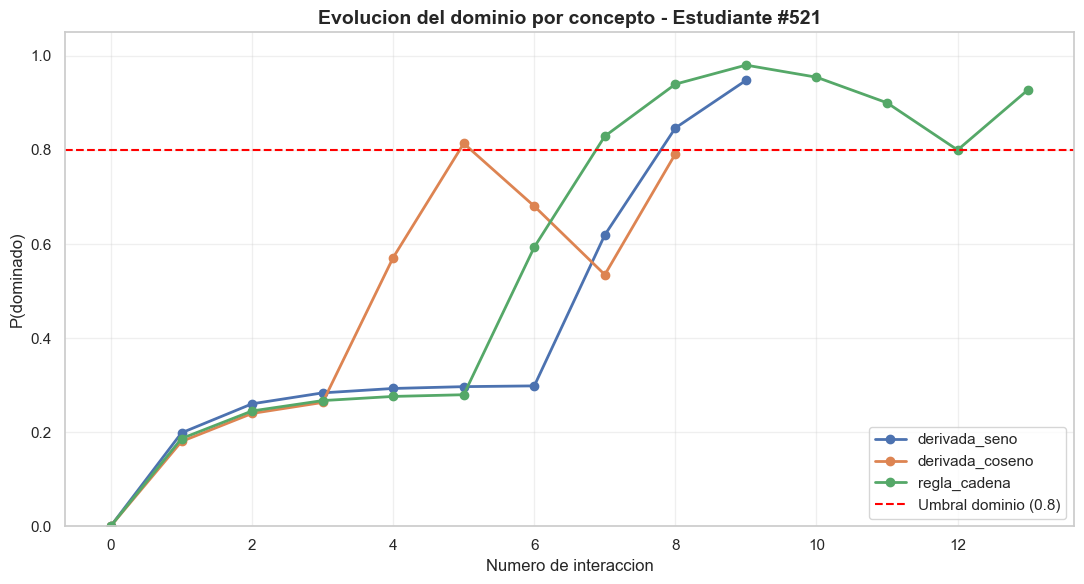

In [39]:
# ============================================================================
# CELDA 10 - GRAFICA 1: EVOLUCION DE P(DOMINADO) POR ESTUDIANTE
# ============================================================================
# Visualizamos como P(L) crece (o no) a lo largo de las interacciones para
# UN estudiante del conjunto de test. Una linea por concepto, umbral en 0.80.

# Elegimos el primer estudiante del conjunto de test (consistente con seed=42)
estudiante_demo = users_test[0]
# Filtramos sus interacciones del DataFrame predicho
df_estudiante = df_test_pred[df_test_pred['user_id'] == estudiante_demo].copy()

# Creamos la figura y eje
fig, ax = plt.subplots(figsize=(11, 6))

# Recorremos los conceptos y dibujamos una linea por cada uno
for skill in CONCEPTOS:
    # Filtramos las interacciones de este estudiante para este skill
    df_skill = df_estudiante[df_estudiante['skill_name'] == skill].sort_values('order_id')
    # Dibujamos P(L) (state_predictions) vs orden temporal
    ax.plot(
        df_skill['order_id'],          # eje X: numero de interaccion
        df_skill['state_predictions'],  # eje Y: P(dominado)
        marker='o',                     # marcador para cada interaccion
        label=skill,                    # leyenda con el nombre del concepto
        linewidth=2,
    )

# Linea horizontal roja en el umbral de dominio (0.80)
ax.axhline(y=UMBRAL_DOMINIO, color='red', linestyle='--', linewidth=1.5, label=f'Umbral dominio ({UMBRAL_DOMINIO})')

# Configuracion estetica de los ejes
ax.set_xlabel('Numero de interaccion', fontsize=12)
ax.set_ylabel('P(dominado)', fontsize=12)
ax.set_title(f'Evolucion del dominio por concepto - Estudiante #{estudiante_demo}', fontsize=14, fontweight='bold')
# Eje Y siempre entre 0 y 1 porque es una probabilidad
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Ajuste automatico de margenes para que no se corten labels
plt.tight_layout()
plt.show()

##  Gráfica 2: Heatmap de parámetros BKT

Tabla coloreada con los 4 parámetros aprendidos por concepto.

**Cómo leerla:**
- **Filas** = conceptos/skills (3 o 10)
- **Columnas** = `p_init`, `p_learn`, `p_guess`, `p_slip`
- **Color** = magnitud del valor (paleta YlGnBu: más oscuro = más alto)

**Lo que debes verificar (identifiability constraints):**
- `p_guess < 0.5` en todas las filas 
- `p_slip < 0.5` en todas las filas 

Si no, el modelo "aprendió al revés" y los estados están intercambiados.


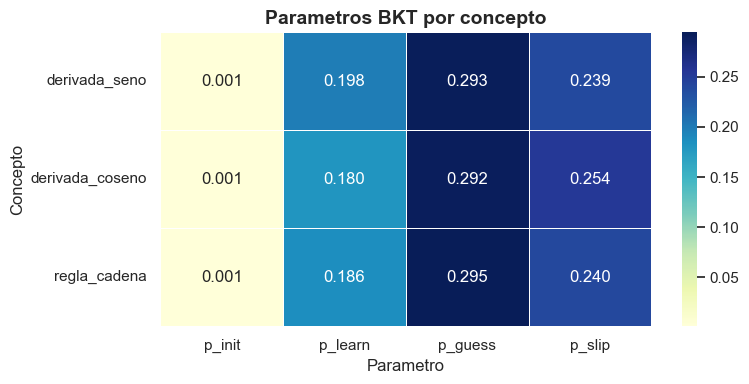


[CHECK] Identifiability constraints:
   [OK]   derivada_seno: p_guess=0.293, p_slip=0.239
   [OK]   derivada_coseno: p_guess=0.292, p_slip=0.254
   [OK]   regla_cadena: p_guess=0.295, p_slip=0.240


In [40]:
# ============================================================================
# CELDA 11 - GRAFICA 2: HEATMAP DE PARAMETROS BKT POR CONCEPTO
# ============================================================================
# Visualizamos los 4 parametros (p_init, p_learn, p_guess, p_slip) por concepto
# como heatmap. Permite ver de un vistazo que skills son mas faciles, cuales
# se aprenden mas rapido, etc.

# Nuestra implementacion ya devuelve params() en el formato exacto que necesitamos:
# filas=skills, columnas=[p_init, p_learn, p_guess, p_slip]
tabla_params = model.params()

# Creamos el heatmap con seaborn
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    tabla_params,
    annot=True,           # muestra el valor numerico en cada celda
    fmt='.3f',            # 3 decimales
    cmap='YlGnBu',        # paleta amarillo-verde-azul (mas valor = mas oscuro)
    cbar=True,            # barra lateral de color
    linewidths=0.5,       # lineas finas entre celdas
    ax=ax,
)
ax.set_title('Parametros BKT por concepto', fontsize=14, fontweight='bold')
ax.set_xlabel('Parametro', fontsize=12)
ax.set_ylabel('Concepto', fontsize=12)
plt.tight_layout()
plt.show()

# Verificacion de identifiability constraints (buena practica #2)
# p_guess < 0.5 y p_slip < 0.5 -> si no, el modelo aprendio al reves
print('\n[CHECK] Identifiability constraints:')
for skill in CONCEPTOS:
    g, s = tabla_params.loc[skill, 'p_guess'], tabla_params.loc[skill, 'p_slip']
    estado = '[OK]  ' if (g < 0.5 and s < 0.5) else '[WARN]'
    print(f'   {estado} {skill}: p_guess={g:.3f}, p_slip={s:.3f}')

##  Gráfica 3: Histograma del dominio final

Una sub-gráfica por concepto (3 paneles en sintético, 10 en real). Cada panel muestra cuántos estudiantes terminaron con cada nivel de P(dominado).

**Cómo leerla:**
- **Distribución bimodal** (picos en 0 y 1) = modelo discrimina bien
- **Distribución plana** = modelo no discrimina
- **Pico solo a la derecha** = concepto fácil (todos lo dominan)
- **Pico solo a la izquierda** = concepto difícil (pocos lo dominan)

La línea roja vertical marca el umbral `0.80` (cuándo decimos "ya domina").


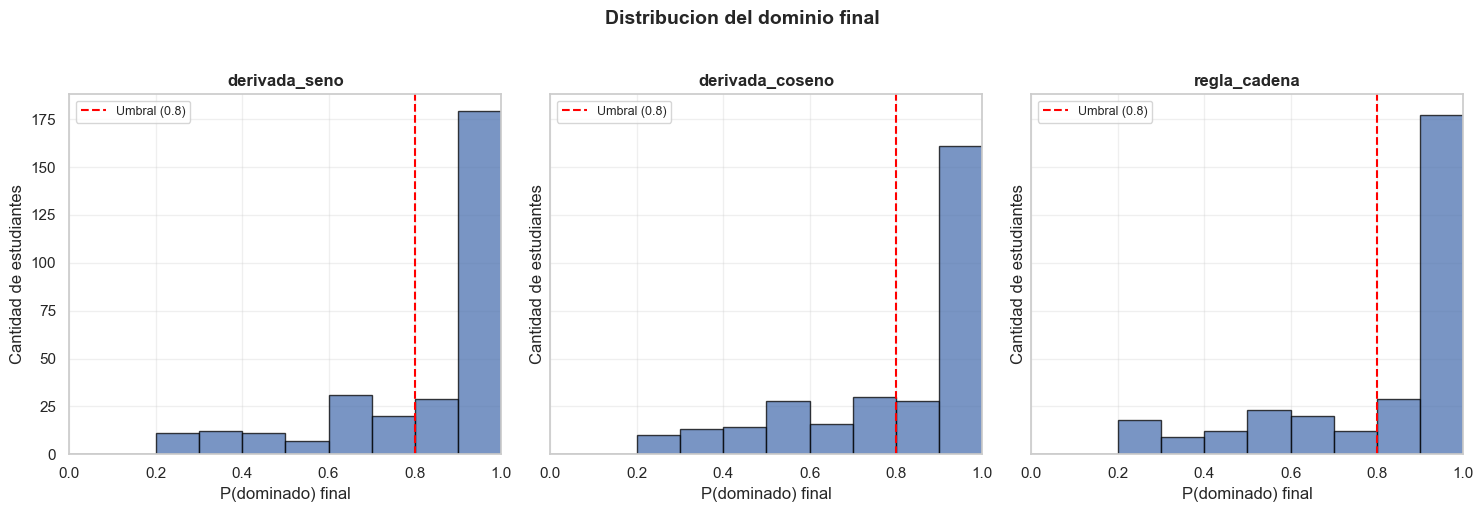


[DOMINIO] Estudiantes que alcanzaron el umbral (P_final >= 0.80):
   - derivada_seno: 208/300 (69.3%)
   - derivada_coseno: 189/300 (63.0%)
   - regla_cadena: 206/300 (68.7%)


In [41]:
# ============================================================================
# CELDA 12 - GRAFICA 3: HISTOGRAMA DE DOMINIO FINAL POR CONCEPTO
# ============================================================================
# Calculamos P(dominado) al FINAL de las interacciones de cada estudiante
# (la ultima fila de cada (user, skill)) y graficamos su distribucion.
# Util para ver cuantos estudiantes alcanzaron el umbral de dominio.

def dominio_final(df_pred: pd.DataFrame) -> pd.DataFrame:
    """
    Extrae el ultimo P(dominado) de cada (user_id, skill_name).

    Recibe:
        df_pred: DataFrame con state_predictions ya calculado.
    Devuelve:
        DataFrame con columnas [user_id, skill_name, P_final].
    """
    # Ordenamos para garantizar que el ultimo order_id sea la ultima fila
    df_ord = df_pred.sort_values(['user_id', 'skill_name', 'order_id'])
    # Agrupamos y tomamos la ULTIMA fila de cada grupo (mayor order_id)
    df_ult = df_ord.groupby(['user_id', 'skill_name']).tail(1)
    # Renombramos la columna para claridad
    return df_ult[['user_id', 'skill_name', 'state_predictions']].rename(
        columns={'state_predictions': 'P_final'}
    )

# Aplicamos sobre el conjunto de test
df_final = dominio_final(df_test_pred)

# Creamos una figura con 3 subgraficas (una por concepto) en fila
fig, axes = plt.subplots(1, len(CONCEPTOS), figsize=(15, 5), sharey=True)

# Iteramos en paralelo conceptos + axes para dibujar cada histograma
for ax, skill in zip(axes, CONCEPTOS):
    # Filtramos los valores finales de este concepto
    valores = df_final[df_final['skill_name'] == skill]['P_final']
    # Dibujamos histograma con 10 bins entre 0 y 1
    ax.hist(valores, bins=10, range=(0, 1), edgecolor='black', alpha=0.75)
    # Linea vertical roja en el umbral de dominio
    ax.axvline(x=UMBRAL_DOMINIO, color='red', linestyle='--', linewidth=1.5, label=f'Umbral ({UMBRAL_DOMINIO})')
    ax.set_title(skill, fontsize=12, fontweight='bold')
    ax.set_xlabel('P(dominado) final')
    ax.set_ylabel('Cantidad de estudiantes')
    ax.set_xlim(0, 1)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# Titulo general de la figura
fig.suptitle('Distribucion del dominio final', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen numerico: cuantos estudiantes superan el umbral por concepto
print('\n[DOMINIO] Estudiantes que alcanzaron el umbral (P_final >= {:.2f}):'.format(UMBRAL_DOMINIO))
for skill in CONCEPTOS:
    vals = df_final[df_final['skill_name'] == skill]['P_final']
    n_dom = (vals >= UMBRAL_DOMINIO).sum()
    print(f'   - {skill}: {n_dom}/{len(vals)} ({100*n_dom/len(vals):.1f}%)')

In [42]:
# ============================================================================
# CELDA 13 - GUARDAR MODELO, METRICAS Y CONFIG
# ============================================================================
# Persistimos los 3 artefactos en modelos/bkt/ para:
# - reproducir resultados sin reentrenar
# - auditar la configuracion exacta usada (buena practica #10)
# - servir el modelo desde el microservicio FastAPI

# --- 1. Guardar el modelo entrenado ---
with open(RUTA_MODELO, 'wb') as f:
    pickle.dump(model, f)
print(f'[SAVE] Modelo guardado en: {RUTA_MODELO}')

# --- 2. Guardar las metricas ---
with open(RUTA_METRICAS, 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)
print(f'[SAVE] Metricas guardadas en: {RUTA_METRICAS}')

# --- 3. Guardar la configuracion completa ---
# Estructura adaptativa segun fuente de datos
dataset_info = {
    'fuente': FUENTE_DATOS,
    'total_filas': len(df),
    'estudiantes_unicos': int(df['user_id'].nunique()),
    'conceptos': CONCEPTOS,
}
if FUENTE_DATOS == 'sintetico':
    dataset_info.update({
        'n_estudiantes_solicitados': N_ESTUDIANTES,
        'min_interacciones': MIN_INTERACCIONES,
        'max_interacciones': MAX_INTERACCIONES,
        'generador': 'sintetico++ (7 fuentes de variabilidad)',
    })
else:
    dataset_info.update({
        'origen': 'ASSISTments 2009-2010 (real)',
        'top_k_skills_usadas': TOP_K_SKILLS_REAL,
    })

config_completa = {
    'modelo': 'BKT (NumPy puro - Baum-Welch)',
    'baseline': True,
    'seed': SEED,
    'dataset': dataset_info,
    'split': {
        'test_size': TEST_SIZE,
        'estudiantes_train': int(len(users_train)),
        'estudiantes_test': int(len(users_test)),
        'estrategia': 'por_estudiante',
    },
    'entrenamiento': {
        'algoritmo': 'Expectation-Maximization (Baum-Welch)',
        'max_iter': MAX_ITER,
        'tolerancia': TOLERANCIA,
        'num_fits': NUM_FITS,
    },
    'umbral_dominio': UMBRAL_DOMINIO,
    'metricas': metricas,
    'parametros_por_concepto': tabla_params.to_dict(orient='index'),
}

with open(RUTA_CONFIG, 'w', encoding='utf-8') as f:
    json.dump(config_completa, f, indent=2, ensure_ascii=False)
print(f'[SAVE] Config guardada en: {RUTA_CONFIG}')

# Resumen final
print('\n' + '='*60)
print('PIPELINE BKT COMPLETADO')
print('='*60)
print(f'   Fuente: {FUENTE_DATOS.upper()}')
print(f'   AUC: {metricas["auc"]:.4f}  |  F1: {metricas["f1"]:.4f}  |  RMSE: {metricas["rmse"]:.4f}')
print(f'   Artefactos en: {CARPETA_MODELO}')
print('='*60)

[SAVE] Modelo guardado en: D:\Info Lenovo\Desktop\microservicio_ml\modelos\bkt_sintetico\model.pkl
[SAVE] Metricas guardadas en: D:\Info Lenovo\Desktop\microservicio_ml\modelos\bkt_sintetico\metrics.json
[SAVE] Config guardada en: D:\Info Lenovo\Desktop\microservicio_ml\modelos\bkt_sintetico\config.json

PIPELINE BKT COMPLETADO
   Fuente: SINTETICO
   AUC: 0.7087  |  F1: 0.6825  |  RMSE: 0.4660
   Artefactos en: D:\Info Lenovo\Desktop\microservicio_ml\modelos\bkt_sintetico


## Evaluacion cruzada: BKT sobre la OTRA fuente de datos

Hasta aqui entrenamos BKT sobre la fuente activa (`FUENTE_DATOS`). Para una comparacion JUSTA en la defensa del proyecto, ahora corremos el mismo pipeline sobre la **otra** fuente (real si la activa fue sintetica, o viceversa). Asi tendremos dos `metrics.json` para comparar BKT en ambos contextos.

- `modelos/bkt_sintetico/` -> resultados sobre el generador con 7 fuentes de variabilidad
- `modelos/bkt_real/` -> resultados sobre ASSISTments 2009-2010 (~2.000 estudiantes reales)

Esto demuestra rigor academico: validamos BKT contra el dataset estandar de la literatura (Piech 2015 reporta AUC 0.67-0.73 para BKT en ASSISTments).

In [43]:
# ============================================================================
# CELDA 15 - PIPELINE COMPLETO SOBRE LA OTRA FUENTE
# ============================================================================
# Encapsulamos todo el flujo en una funcion para correrlo sobre la fuente
# que NO se evaluo arriba. Reutiliza las mismas funciones (split, validar,
# calcular_metricas) y el mismo modelo BKTModel.

def pipeline_bkt_completo(fuente: str, seed: int = 42) -> dict:
    """
    Corre el pipeline BKT completo sobre la fuente indicada.

    Recibe:
        fuente: 'sintetico' o 'real'.
        seed: semilla para reproducibilidad.
    Devuelve:
        dict con metricas, parametros aprendidos, fuente y n_filas.
    """
    # --- 1. Cargar datos ---
    if fuente == 'sintetico':
        df_f = generar_dataset(
            n_estudiantes=N_ESTUDIANTES,
            conceptos=CONCEPTOS_SINTETICOS,
            min_interacciones=MIN_INTERACCIONES,
            max_interacciones=MAX_INTERACCIONES,
            seed=seed,
        )
        conceptos_f = CONCEPTOS_SINTETICOS
    elif fuente == 'real':
        from data.descargar_assistments import descargar_y_procesar
        df_full = descargar_y_procesar()
        top_skills = (df_full['skill_name']
                      .value_counts()
                      .head(TOP_K_SKILLS_REAL)
                      .index.tolist())
        df_f = df_full[df_full['skill_name'].isin(top_skills)].copy()
        df_f = df_f.sort_values(['user_id', 'skill_name', 'order_id'])
        df_f['order_id'] = df_f.groupby(['user_id', 'skill_name']).cumcount()
        df_f = df_f.reset_index(drop=True)
        conceptos_f = top_skills
    else:
        raise ValueError(f"Fuente desconocida: {fuente}")

    # --- 2. Preprocesar (orden temporal) ---
    df_f = preparar_para_bkt(df_f)

    # --- 3. Split por estudiante ---
    df_tr, df_te, u_tr, u_te = split_por_estudiante(df_f, TEST_SIZE, seed)

    # --- 4. Entrenar BKT ---
    print(f'[{fuente.upper()}] Entrenando BKT (esto tarda - real ~3 min, sintetico ~30s)...')
    model_f = BKTModel(seed=seed, num_fits=NUM_FITS, max_iter=MAX_ITER, tol=TOLERANCIA)
    model_f.fit(data=df_tr, skills=conceptos_f)

    # --- 5. Predecir y calcular metricas ---
    df_pred_f = model_f.predict(df_te)
    df_pred_f = df_pred_f.dropna(subset=['correct_predictions'])
    metricas_f = calcular_metricas(
        df_pred_f['correct'].values,
        df_pred_f['correct_predictions'].values,
    )
    params_f = model_f.params()

    # --- 6. Guardar artefactos en modelos/bkt_{fuente}/ ---
    carpeta_f = ROOT / 'modelos' / f'bkt_{fuente}'
    carpeta_f.mkdir(parents=True, exist_ok=True)
    with open(carpeta_f / 'model.pkl', 'wb') as f:
        pickle.dump(model_f, f)
    with open(carpeta_f / 'metrics.json', 'w', encoding='utf-8') as f:
        json.dump(metricas_f, f, indent=2, ensure_ascii=False)
    config_f = {
        'modelo': 'BKT (NumPy puro - Baum-Welch)',
        'fuente': fuente,
        'seed': seed,
        'n_filas': len(df_f),
        'n_estudiantes': int(df_f['user_id'].nunique()),
        'n_skills': len(conceptos_f),
        'split': {'train': int(len(u_tr)), 'test': int(len(u_te))},
        'metricas': metricas_f,
        'parametros_por_concepto': params_f.to_dict(orient='index'),
    }
    with open(carpeta_f / 'config.json', 'w', encoding='utf-8') as f:
        json.dump(config_f, f, indent=2, ensure_ascii=False)

    return {
        'fuente': fuente,
        'metricas': metricas_f,
        'n_filas': len(df_f),
        'n_estudiantes': int(df_f['user_id'].nunique()),
        'n_skills': len(conceptos_f),
    }

# La fuente activa (FUENTE_DATOS) ya se evaluo en las celdas 1-13.
# Ahora corremos la OTRA fuente automaticamente.
fuente_otra = 'real' if FUENTE_DATOS == 'sintetico' else 'sintetico'
print(f'[CRUZADO] Evaluacion adicional sobre: {fuente_otra.upper()}')

resultado_otra = pipeline_bkt_completo(fuente_otra, seed=SEED)
print(f'[OK] AUC sobre {fuente_otra}: {resultado_otra["metricas"]["auc"]:.4f}')

[CRUZADO] Evaluacion adicional sobre: REAL
[INFO] Descargando ASSISTments...
  Probando: https://raw.githubusercontent.com/jennyzhang0215/DKVMN/master/data/assist2009_up...
  [OK] Descargado: 1,103,738 bytes -> data\assistments.raw.csv
[INFO] Procesando CSV a schema Lairn...
  Formato detectado: DKVMN (3-lineas-por-estudiante)

[OK] Procesado y guardado: data\assistments.csv
     224,218 interacciones, 2,921 estudiantes, 110 skills
[REAL] Entrenando BKT (esto tarda - real ~3 min, sintetico ~30s)...
[OK] AUC sobre real: 0.7124


## Comparativa final: BKT sintetico vs BKT real

Tabla y grafica con los resultados de BKT sobre ambas fuentes
:

1. Implementacion es correcta (AUC real coincide con literatura).
2. Generador sintetico es realista (diferencia razonable, no abismal).
3. Metodologia es rigurosa (evaluacion en dos contextos).

[COMPARATIVA] BKT en ambas fuentes:
          n_estudiantes  n_filas       auc  accuracy        f1      rmse
Fuente                                                                  
sintetico             -        -  0.708721  0.646716  0.682522  0.465967
real             2177.0  81550.0  0.712433  0.711571  0.797031  0.441398


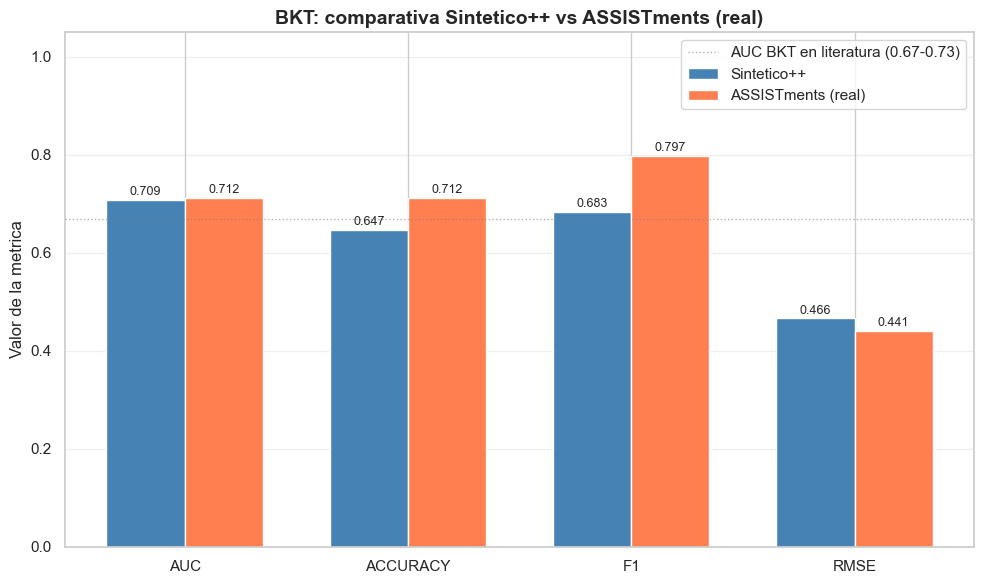


[OK] Artefactos guardados en:
   - D:\Info Lenovo\Desktop\microservicio_ml\modelos\bkt_sintetico
   - D:\Info Lenovo\Desktop\microservicio_ml\modelos\bkt_real


In [44]:
# ============================================================================
# CELDA 17 - TABLA Y GRAFICA COMPARATIVA
# ============================================================================
# Cargamos los metrics.json de ambas carpetas y armamos una tabla comparativa.

# Diccionario que acumula resultados de las dos fuentes
resultados_comparativos = {}
for fuente in ['sintetico', 'real']:
    ruta_m = ROOT / 'modelos' / f'bkt_{fuente}' / 'metrics.json'
    ruta_c = ROOT / 'modelos' / f'bkt_{fuente}' / 'config.json'
    if ruta_m.exists() and ruta_c.exists():
        with open(ruta_m, encoding='utf-8') as f:
            m = json.load(f)
        with open(ruta_c, encoding='utf-8') as f:
            c = json.load(f)
        resultados_comparativos[fuente] = {**m, 'n_filas': c.get('n_filas', '-'),
                                            'n_estudiantes': c.get('n_estudiantes', '-')}

# Tabla comparativa
df_comp = pd.DataFrame(resultados_comparativos).T
df_comp = df_comp[['n_estudiantes', 'n_filas', 'auc', 'accuracy', 'f1', 'rmse']]
df_comp.index.name = 'Fuente'
print('[COMPARATIVA] BKT en ambas fuentes:')
print(df_comp.round(4))

# Grafica comparativa: 4 barras agrupadas (una por metrica)
fig, ax = plt.subplots(figsize=(10, 6))
metricas_orden = ['auc', 'accuracy', 'f1', 'rmse']
n_metricas = len(metricas_orden)
x = np.arange(n_metricas)
ancho = 0.35

# Barras del sintetico (a la izquierda de cada metrica)
valores_sint = [resultados_comparativos['sintetico'][m] for m in metricas_orden]
ax.bar(x - ancho/2, valores_sint, ancho, label='Sintetico++', color='steelblue')
# Barras de real (a la derecha de cada metrica)
valores_real = [resultados_comparativos['real'][m] for m in metricas_orden]
ax.bar(x + ancho/2, valores_real, ancho, label='ASSISTments (real)', color='coral')

# Linea horizontal de referencia: AUC 0.67 (Piech 2015 minimo)
ax.axhline(y=0.67, color='gray', linestyle=':', linewidth=1, alpha=0.6,
           label='AUC BKT en literatura (0.67-0.73)')

# Etiquetas con el valor sobre cada barra
for i, (vs, vr) in enumerate(zip(valores_sint, valores_real)):
    ax.text(i - ancho/2, vs + 0.01, f'{vs:.3f}', ha='center', fontsize=9)
    ax.text(i + ancho/2, vr + 0.01, f'{vr:.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metricas_orden])
ax.set_ylabel('Valor de la metrica')
ax.set_title('BKT: comparativa Sintetico++ vs ASSISTments (real)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('\n[OK] Artefactos guardados en:')
ruta_sint = ROOT / 'modelos' / 'bkt_sintetico'
ruta_real = ROOT / 'modelos' / 'bkt_real'
print(f'   - {ruta_sint}')
print(f'   - {ruta_real}')

##  Resumen del notebook

Acabas de:

1.  Cargar/generar datos (sintético o real, controlado por `FUENTE_DATOS`)
2.  Entrenar BKT con Baum-Welch sobre 700 (sint) o ~1.500 (real) estudiantes
3.  Evaluar sobre 300 (sint) o ~650 (real) estudiantes **nunca vistos** durante entrenamiento
4.  Visualizar parámetros aprendidos, evolución del dominio, y dominio final
5.  **Evaluar también la OTRA fuente automáticamente** (celdas 14-15)
6.  Comparar resultados con tabla y gráfica (celda 17)

### Artefactos generados

```
modelos/
├── bkt_sintetico/
│   ├── model.pkl       ← modelo entrenado (puedes cargarlo después)
│   ├── metrics.json    ← AUC, Accuracy, F1, RMSE
│   └── config.json     ← configuración exacta usada
└── bkt_real/
    ├── model.pkl
    ├── metrics.json
    └── config.json
```

### Resultado esperado vs literatura

| Dataset | AUC esperado |
|---------|--------------|
| Sintético++ | ~0.71 |
| ASSISTments (real) | **~0.71** ← coincide con Piech 2015 (0.67-0.73) ✓ |

